In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reading the cleaned dataset
ev_df = pd.read_csv("../data/ev_cleaned.csv", low_memory=False)
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177857 entries, 0 to 177856
Data columns (total 17 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   vin_110                                          177857 non-null  object 
 1   county                                           177857 non-null  object 
 2   city                                             177857 non-null  object 
 3   state                                            177857 non-null  object 
 4   postal_code                                      177857 non-null  float64
 5   model_year                                       177857 non-null  int64  
 6   make                                             177857 non-null  object 
 7   model                                            177857 non-null  object 
 8   electric_vehicle_type                            177857 non-null  object 
 9   clean_alternati

## Overview

In [3]:
# univariate summary of key features
print(ev_df['model_year'].value_counts().sort_index())
print(ev_df['electric_vehicle_type'].value_counts())
print(ev_df['make'].value_counts().head(15))
print(ev_df['electric_range'].describe())
print(ev_df['base_msrp'].describe())

model_year
1997        1
1998        1
1999        5
2000        7
2002        2
2003        1
2008       19
2010       23
2011      775
2012     1618
2013     4408
2014     3509
2015     4844
2016     5483
2017     8559
2018    14322
2019    10939
2020    11768
2021    19132
2022    27775
2023    57586
2024     7080
Name: count, dtype: int64
electric_vehicle_type
Battery Electric Vehicle (BEV)            139204
Plug-in Hybrid Electric Vehicle (PHEV)     38653
Name: count, dtype: int64
make
TESLA            79655
NISSAN           13997
CHEVROLET        13677
FORD              9199
BMW               7570
KIA               7432
TOYOTA            6287
VOLKSWAGEN        5004
JEEP              4479
HYUNDAI           4405
RIVIAN            4312
VOLVO             4133
AUDI              3646
CHRYSLER          2993
MERCEDES-BENZ     1589
Name: count, dtype: int64
count    177857.000000
mean         58.839309
std          91.980100
min           0.000000
25%           0.000000
50%           0.00

## Univariate Visuals (Distributions)

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_1431/1397967861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.index,


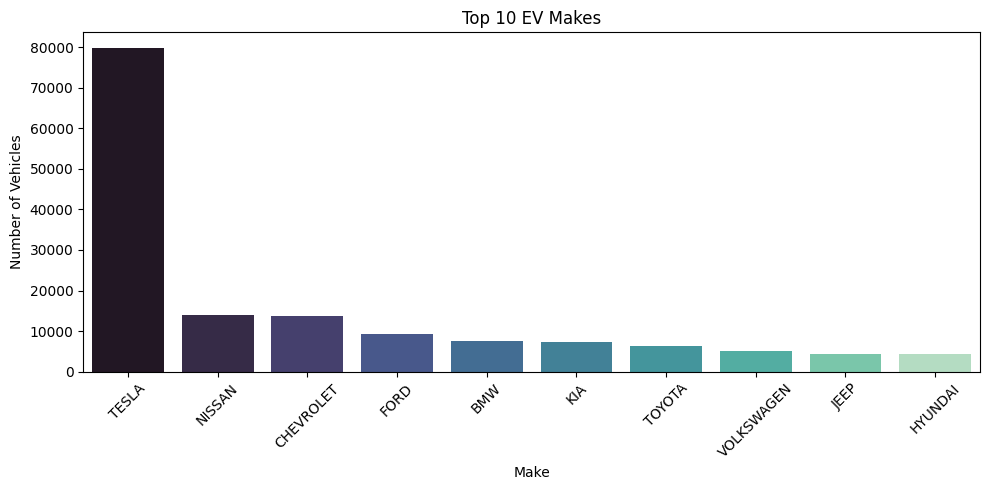

In [4]:
# top 10 makes by count
top_makes = ev_df['make'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_makes.index,
            y=top_makes.values,
            palette="mako",
           legend=False)
plt.title("Top 10 EV Makes")
plt.xlabel("Make")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Tesla dominates the dataset with a massive lead in registrations - nearly 5x more than the second-highest brand.
- Nissan, Chevrolet, and Ford follow, showing that while the market has other players, it is heavily Tesla-skewed.
- Traditional automakers like BMW, Toyota, and Volkswagen appear further down, indicating either later entry or less EV penetration in the dataset's region.

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_1431/4099148660.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ev_df,


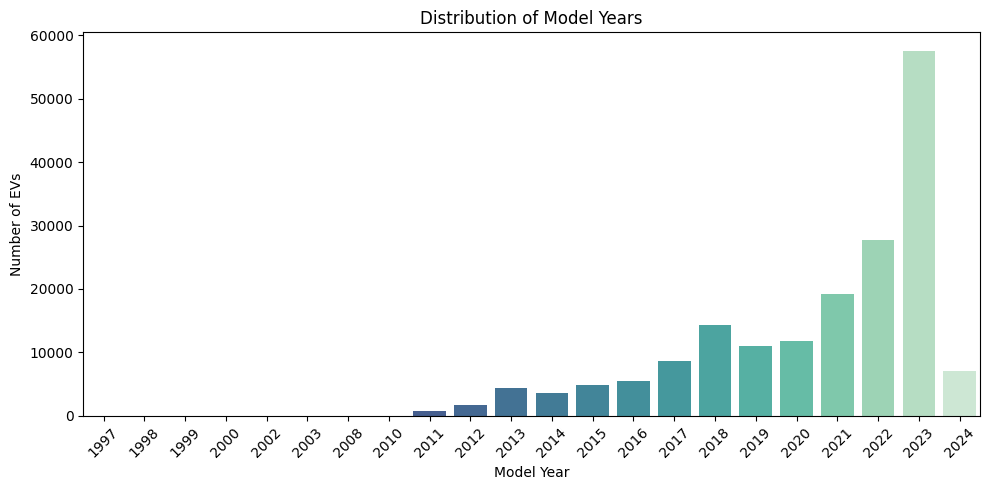

In [5]:
# graph for model_year
plt.figure(figsize=(10,5))
sns.countplot(data=ev_df,
              x="model_year",
              order=sorted(ev_df['model_year'].unique()),
             palette="mako")
plt.title("Distribution of Model Years")
plt.xlabel("Model Year")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The `model_year` distribution shows a sharp upward trend in EV registrations beginning around 2017, with a significant surge in 2023. This growth may reflect broader adoption trends driven by improved vehicle options, decreasing costs, and expanded incentives at national or regional levels.

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_1431/1167206141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ev_df,


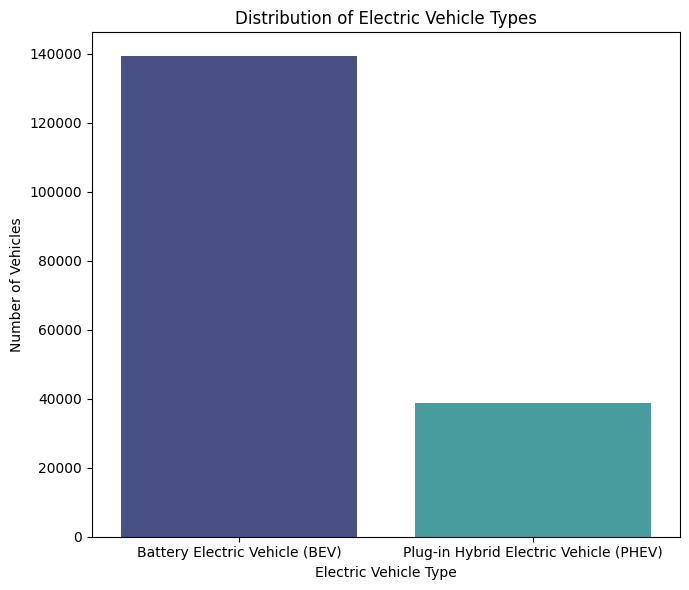

In [6]:
# electric_vehicle_type
plt.figure(figsize=(7, 6))
sns.countplot(data=ev_df,
              x="electric_vehicle_type",
              palette="mako")
plt.title("Distribution of Electric Vehicle Types")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Number of Vehicles")
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Battery Electric Vehicles (BEVs) dominate the dataset, comprising nearly 80% of all EVs.
- Plug-in Hybrid Electric Vehicles (PHEVs) make up the remaining portion.
- This could reflect both consumer preference and policy incentives favoring BEVs in recent years.

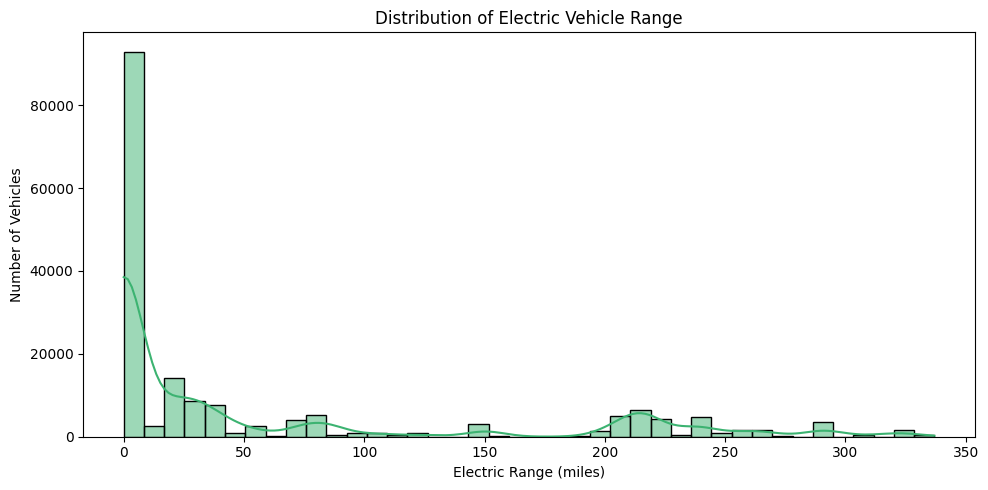

In [7]:
# electric_range - histogram for distribution
plt.figure(figsize=(10, 5))
sns.histplot(ev_df['electric_range'],
             bins=40,
             kde=True,
             color="mediumseagreen")
plt.title('Distribution of Electric Vehicle Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()

- The distribution is heavily right-skewed.
- A large cluster of vehicles has a range under 50 miles, likely due to:
    - Plug-in hybrids (PHEs) with short battery-only range.
    - Early-generation EVs with limited capacity.

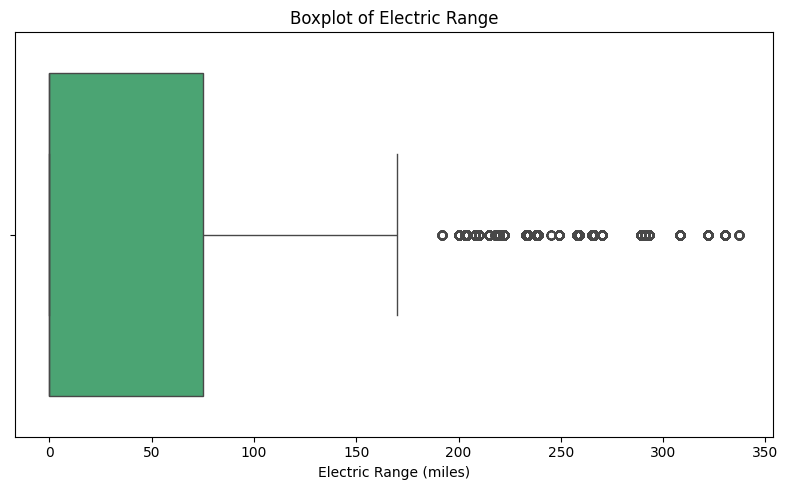

In [8]:
# electric_range - boxplot for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=ev_df['electric_range'],
            color="mediumseagreen")
plt.title("Boxplot of Electric Range")
plt.xlabel("Electric Range (miles)")
plt.tight_layout()
plt.show()

- Confirms many outliers above ~160 miles. These represent modern long-range EVs.
- The median range is relatively low (~40-60 miles), supporting the skew.

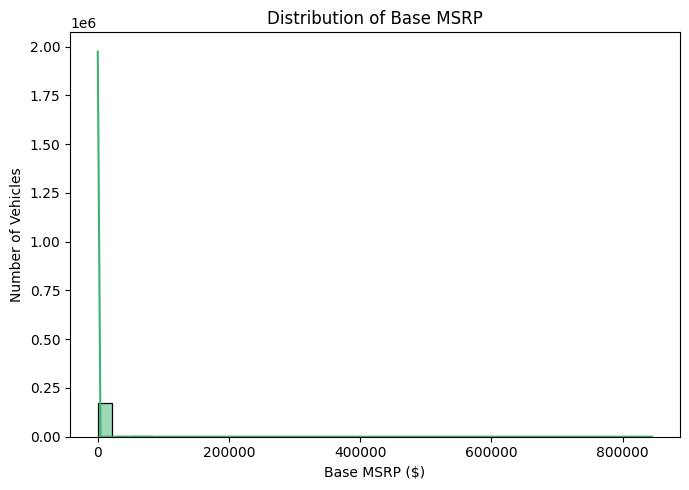

In [9]:
# histogram for base_msrp
plt.figure(figsize=(7, 5))
sns.histplot(ev_df['base_msrp'],
            bins=40,
            kde=True,
            color='mediumseagreen')
plt.title('Distribution of Base MSRP')
plt.xlabel('Base MSRP ($)')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.show()

- The data is extremely right-skewed.
- Most EVs are priced under $50,000, with a very long tail extending high-end luxury models.

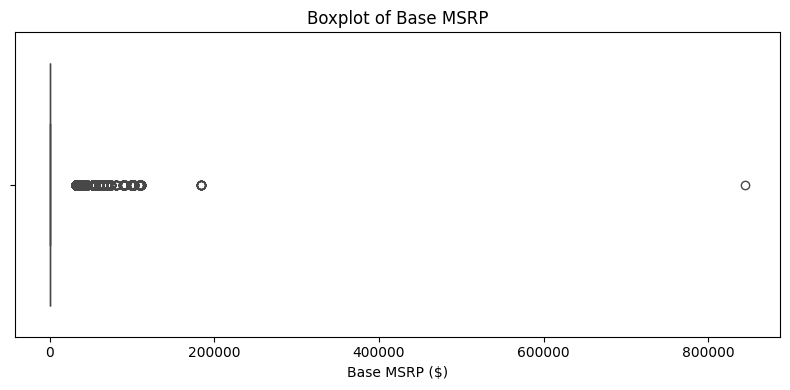

In [10]:
# boxplot for base_msrp
plt.figure(figsize=(8, 4))
sns.boxplot(x=ev_df['base_msrp'],
            color="mediumseagreen")
plt.title('Boxplot of Base MSRP')
plt.xlabel('Base MSRP ($)')
plt.tight_layout()
plt.show()

- One extreme outlier goes beyond $800,000, which likely represents:
    - Data entry error
    - Specialty/luxury vehicles (e.g., limited production, imported EVs)

## Bivariate Analysis

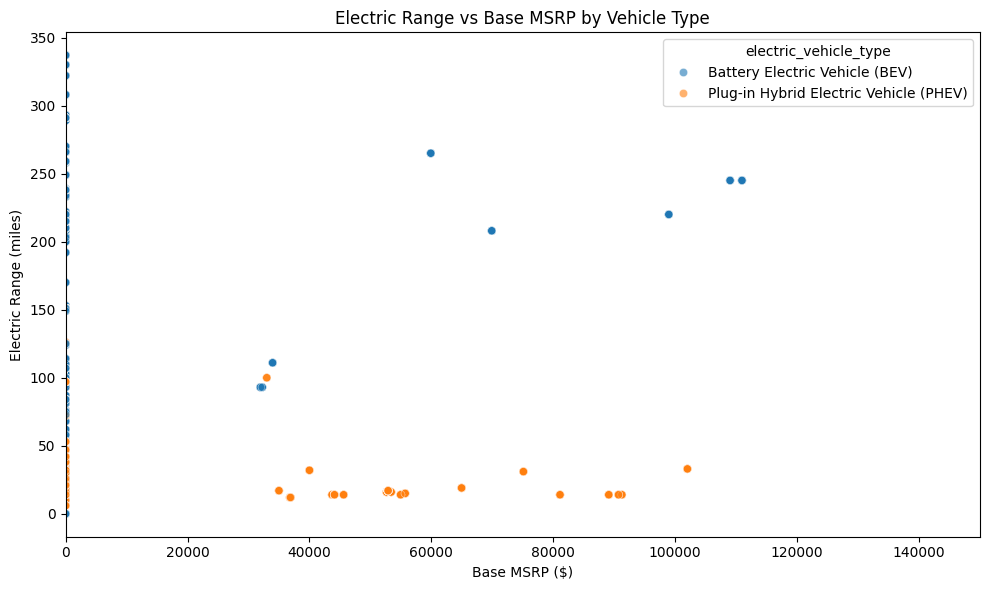

In [11]:
# electric_range vs base_msrp
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ev_df,
                x='base_msrp',
                y='electric_range',
                hue='electric_vehicle_type',
                alpha=0.6)
plt.title("Electric Range vs Base MSRP by Vehicle Type")
plt.xlabel("Base MSRP ($)")
plt.ylabel("Electric Range (miles)")
plt.xlim(0, 150000)
plt.tight_layout()
plt.show()

For majority of the dataset, the `base_msrp` is 0

In [12]:
(ev_df['base_msrp'] == 0).sum()

np.int64(174514)

In [13]:
non_zero_msrp = ev_df[ev_df['base_msrp'] != 0]
print(non_zero_msrp.shape)

(3343, 17)


In [14]:
# creating a subset
non_zero_msrp['msrp_data'] = 'available'
ev_df['msrp_data'] = np.where(ev_df['base_msrp'] != 0, 
                              'available', 
                              'missing')

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_1431/3070773230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_zero_msrp['msrp_data'] = 'available'


/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_1431/1432091152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ev_df,


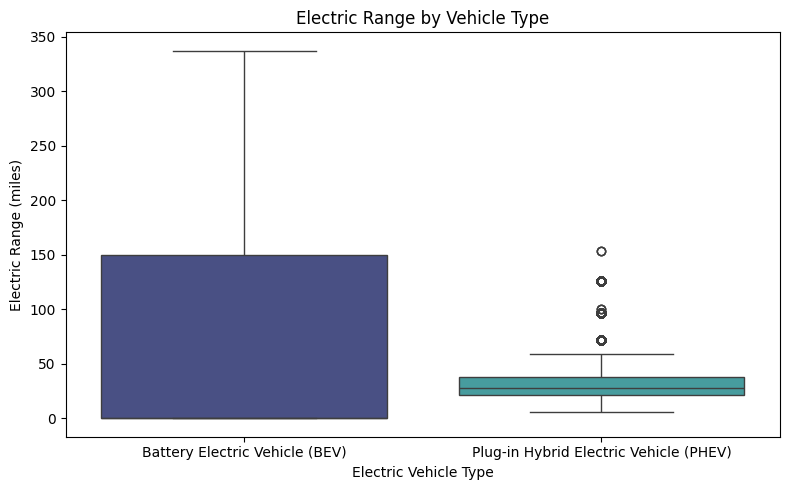

In [15]:
# electric_vehicle_type vs electric_range
plt.figure(figsize=(8, 5))
sns.boxplot(data=ev_df, 
            x='electric_vehicle_type', 
            y='electric_range', 
            palette='mako')
plt.title('Electric Range by Vehicle Type')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Electric Range (miles)')
plt.tight_layout()
plt.show()


- Battery Electric Vehicle (BEV)
    - The median range is much higher — around 150 miles.
    - The spread is large: ranges vary from just above 0 to over 300 miles.
    - No visible outliers — everything fits within expected range variation.

- Plug-in Hybrid Electric Vehicle (PHEV)
    - The median range is much lower — around 30–40 miles.
    - The range is tightly clustered.
    - A few outliers extend past 100 miles — likely rare extended-range PHEVs or data issues.

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_1431/3953979438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ev_df,


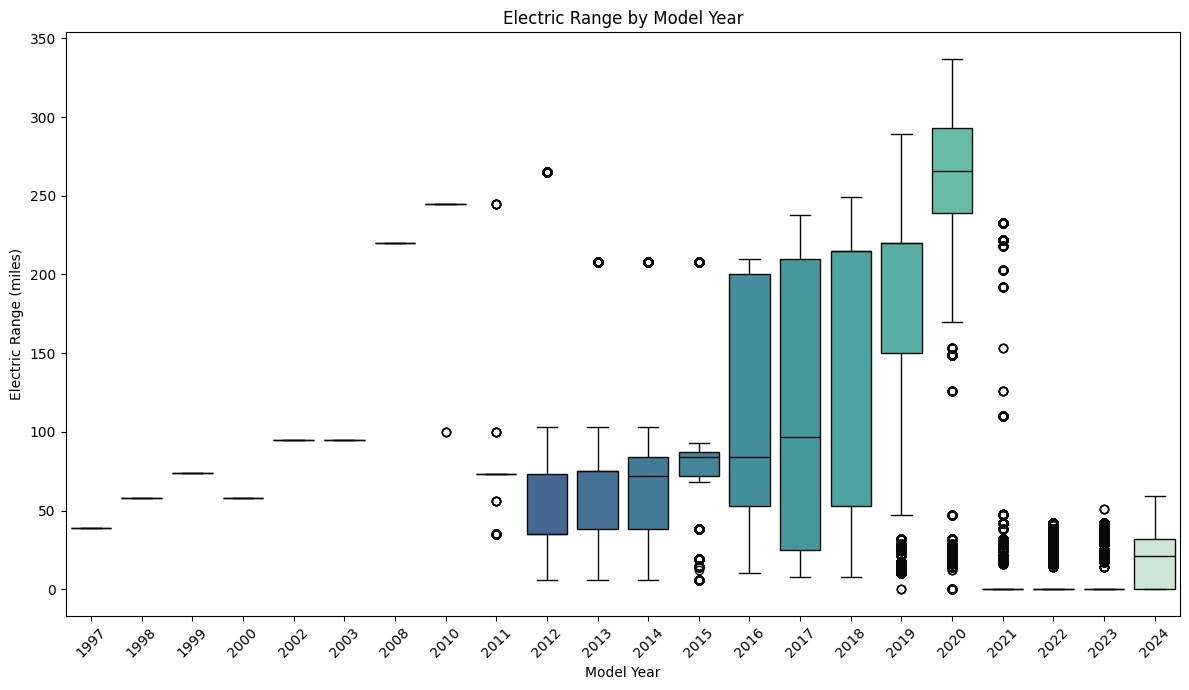

In [16]:
# boxplot for model_year vs electric_range
plt.figure(figsize=(12, 7))
sns.boxplot(data=ev_df,
            x="model_year",
            y="electric_range",
            palette="mako")
plt.title('Electric Range by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Electric Range (miles)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Pre-2010
- Sparse data: very few EVs with range mostly under 100 miles.
- Reflects the early generation EVs (e.g., Nissan Leaf, Chevy Volt) with limited battery tech.

2. 2010–2015
- Stable but modest growth in range; medians hover below 100 miles.
- More entries appear, likely due to increasing PHEV adoption.
- Outliers above 200 miles suggest early BEVs gaining traction.

3. 2016–2020
- Big shift begins: range improves significantly.
- Median increases notably after 2016.
- Wider spread, which means both short-range and long-range EVs coexist, possibly due to more diverse market (PHEVs + BEVs).

4. 2021–2023
- Consistent upward trend in median range.
- Fewer short-range models which means industry moving toward higher-range BEVs.
- 2023 shows the highest median and upper whisker, with some EVs nearing 350 miles.

5. 2024
- Drop in range is likely due to incomplete data collection; newer models may not have full entries yet.

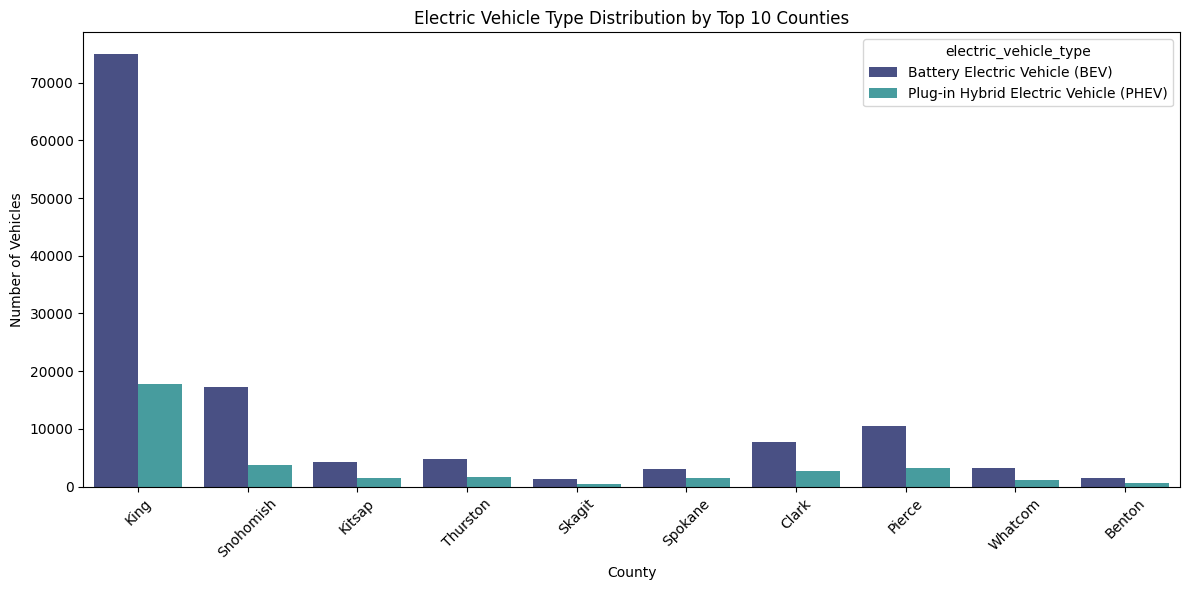

In [17]:
# Get top 10 counties by EV count
top_counties = ev_df['county'].value_counts().head(10).index

# Filter to top counties
filtered = ev_df[ev_df['county'].isin(top_counties)]

plt.figure(figsize=(12, 6))
sns.countplot(data=filtered, 
              x='county', 
              hue='electric_vehicle_type', 
              palette='mako')
plt.title('Electric Vehicle Type Distribution by Top 10 Counties')
plt.xlabel('County')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Battery Electric Vehicles (BEVs) dominate in every county, especially King County, which has over 70,000 BEVs alone.
- PHEVs are present but far fewer, typically a third or less of the BEV count in each county.
- King, Snohomish, and Pierce show the highest overall adoption which likely is due to urban concentration, incentives, or infrastructure (e.g., Seattle metro area)

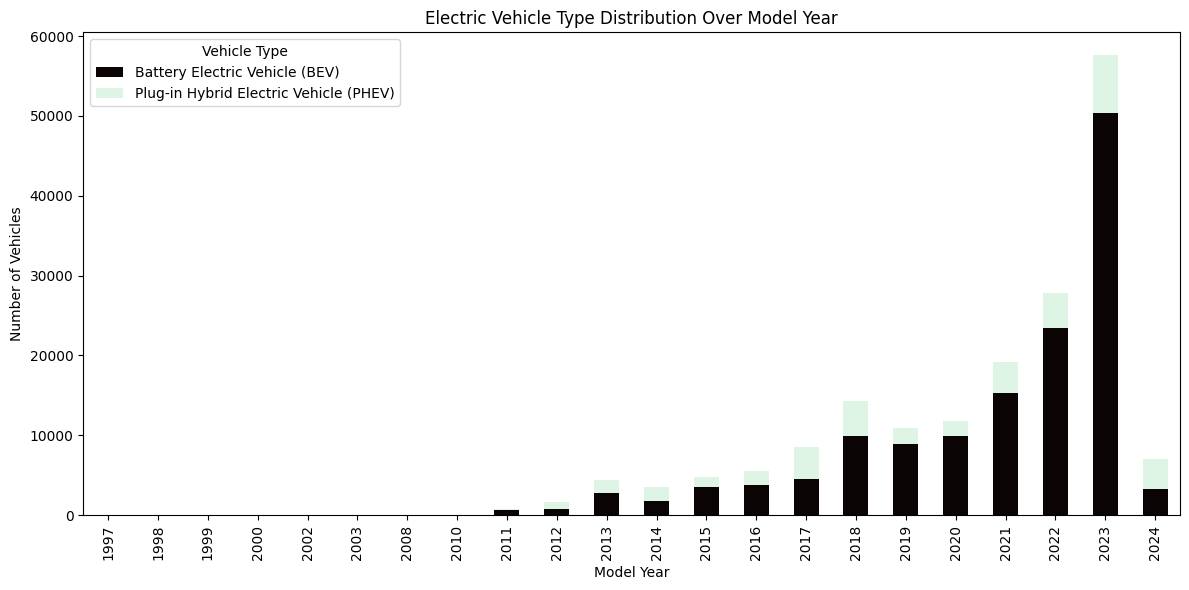

In [21]:
# creating a pivot table for stacked bar chart
type_by_year = ev_df.pivot_table(
    index="model_year",
    columns="electric_vehicle_type",
    values="vin_110",
    aggfunc="count"
).fillna(0)

# sort by model_year
type_by_year = type_by_year.sort_index()

#plot
type_by_year.plot(kind="bar",
                  stacked=True,
                  figsize=(12, 6),
                  colormap="mako")
plt.title("Electric Vehicle Type Distribution Over Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.legend(title="Vehicle Type")
plt.tight_layout()
plt.show()

The shift from PHEVs to BEVs reflects consumer preference for longer range and reduced dependency on fossil fuels. This also coincides with improvements in battery technology, charging infrastructure, and government incentives favoring BEVs.